In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path("../assets/dataset/CSV/diabetes_all_patients_code.csv")

TARGET_CODES = {"58", "60", "62", "64"}
GLUCOSE_CODES = {"48", "57", "58", "59", "60", "61", "62", "63", "64"}

RANDOM_STATE = 0

In [2]:
df = pd.read_csv(DATA_PATH, sep=None, engine="python")

df["patientId"] = pd.to_numeric(df["patientId"], errors="coerce").astype("Int64")
df["Day"] = pd.to_numeric(df["Day"], errors="coerce")
df["MinuteOfDay"] = pd.to_numeric(df["MinuteOfDay"], errors="coerce")
df["Code"] = df["Code"].astype(str)
df["ValueNum"] = pd.to_numeric(df["Value"], errors="coerce")

# Patient-relative absolute time.
df["AbsMinute"] = (df["Day"] - 1) * 1440 + df["MinuteOfDay"]

df = (
    df.dropna(subset=["patientId", "Day", "MinuteOfDay", "AbsMinute"])
      .sort_values(["patientId", "AbsMinute"])
      .reset_index(drop=True)
)

df["patientId"] = df["patientId"].astype(int)

df.head()


,patientId,Day,MinuteOfDay,Code,Value,CodeMeaning,ValueNum,AbsMinute
0,1,1,549.0,58,100,Pre-breakfast blood glucose measurement,100.0,549.0
1,1,1,549.0,33,009,Regular insulin dose,9.0,549.0
2,1,1,549.0,34,013,NPH insulin dose,13.0,549.0
3,1,1,1028.0,62,119,Pre-supper blood glucose measurement,119.0,1028.0
4,1,1,1028.0,33,007,Regular insulin dose,7.0,1028.0


In [3]:
def build_modeling_rows(patient_df):
    rows = []
    history = []

    for _, row in patient_df.iterrows():
        code = row["Code"]
        t = row["AbsMinute"]
        value = row["ValueNum"]

        if code in TARGET_CODES and pd.notna(value):
            prior = [e for e in history if e["time"] < t]

            def prior_events(codes, hours):
                cutoff = t - hours * 60
                return [
                    e for e in prior
                    if e["code"] in codes and e["time"] >= cutoff
                ]

            def sum_values(codes, hours):
                return sum(
                    e["value"] for e in prior_events(codes, hours)
                    if pd.notna(e["value"])
                )

            def count_events(codes, hours):
                return len(prior_events(codes, hours))

            def glucose_events(hours=None, same_code=None):
                events = [
                    e for e in prior
                    if e["code"] in GLUCOSE_CODES and pd.notna(e["value"])
                ]

                if same_code is not None:
                    events = [e for e in events if e["code"] == same_code]

                if hours is not None:
                    cutoff = t - hours * 60
                    events = [e for e in events if e["time"] >= cutoff]

                return events

            all_prev_glucose = glucose_events()
            same_target_glucose = glucose_events(same_code=code)

            if all_prev_glucose:
                last_glucose = all_prev_glucose[-1]
                prev_glucose = last_glucose["value"]
                hours_since_prev_glucose = (t - last_glucose["time"]) / 60
            else:
                prev_glucose = np.nan
                hours_since_prev_glucose = np.nan

            if same_target_glucose:
                last_same = same_target_glucose[-1]
                prev_same_target_glucose = last_same["value"]
                hours_since_same_target = (t - last_same["time"]) / 60
            else:
                prev_same_target_glucose = np.nan
                hours_since_same_target = np.nan

            glucose_24h = glucose_events(hours=24)
            glucose_48h = glucose_events(hours=48)
            glucose_7d = glucose_events(hours=24 * 7)

            def mean_or_nan(events):
                values = [e["value"] for e in events if pd.notna(e["value"])]
                return np.mean(values) if values else np.nan

            def min_or_nan(events):
                values = [e["value"] for e in events if pd.notna(e["value"])]
                return np.min(values) if values else np.nan

            def max_or_nan(events):
                values = [e["value"] for e in events if pd.notna(e["value"])]
                return np.max(values) if values else np.nan

            minute = row["MinuteOfDay"]

            rows.append({
                "patientId": row["patientId"],
                "target_code": code,
                "Day": row["Day"],
                "MinuteOfDay": minute,
                "time_sin": np.sin(2 * np.pi * minute / 1440),
                "time_cos": np.cos(2 * np.pi * minute / 1440),

                "prev_glucose": prev_glucose,
                "hours_since_prev_glucose": hours_since_prev_glucose,
                "prev_same_target_glucose": prev_same_target_glucose,
                "hours_since_same_target": hours_since_same_target,

                "glucose_mean_24h": mean_or_nan(glucose_24h),
                "glucose_min_24h": min_or_nan(glucose_24h),
                "glucose_max_24h": max_or_nan(glucose_24h),
                "glucose_mean_48h": mean_or_nan(glucose_48h),
                "glucose_mean_7d": mean_or_nan(glucose_7d),

                "regular_insulin_2h": sum_values({"33"}, 2),
                "regular_insulin_4h": sum_values({"33"}, 4),
                "regular_insulin_8h": sum_values({"33"}, 8),

                "nph_insulin_12h": sum_values({"34"}, 12),
                "nph_insulin_24h": sum_values({"34"}, 24),

                "ultralente_insulin_24h": sum_values({"35"}, 24),
                "ultralente_insulin_36h": sum_values({"35"}, 36),

                "typical_meal_6h": count_events({"66"}, 6),
                "more_meal_6h": count_events({"67"}, 6),
                "less_meal_6h": count_events({"68"}, 6),

                "typical_exercise_6h": count_events({"69"}, 6),
                "more_exercise_6h": count_events({"70"}, 6),
                "less_exercise_6h": count_events({"71"}, 6),

                "hypo_symptoms_24h": count_events({"65"}, 24),
                "special_event_24h": count_events({"72"}, 24),

                "glucose": value,
            })

        history.append({
            "time": t,
            "code": code,
            "value": value,
        })

    return rows


In [4]:
# Build Modeling Table
model_rows = []

for _, patient_df in df.groupby("patientId"):
    model_rows.extend(build_modeling_rows(patient_df))

model_df = pd.DataFrame(model_rows)

print("Modeling rows:", model_df.shape)
model_df.head()

Modeling rows: (10346, 31)


,patientId,target_code,Day,MinuteOfDay,time_sin,time_cos,prev_glucose,hours_since_prev_glucose,prev_same_target_glucose,hours_since_same_target,...,ultralente_insulin_36h,typical_meal_6h,more_meal_6h,less_meal_6h,typical_exercise_6h,more_exercise_6h,less_exercise_6h,hypo_symptoms_24h,special_event_24h,glucose
0,1,58,1,549.0,0.678801,-0.734323,NaN,NaN,NaN,NaN,...,0.0,0,0,0,0,0,0,0,0,100.0
1,1,62,1,1028.0,-0.974370,-0.224951,100.0,7.983333,NaN,NaN,...,0.0,0,0,0,0,0,0,0,0,119.0
2,1,58,2,455.0,0.915311,-0.402747,123.0,8.733333,100.0,22.433333,...,0.0,0,0,0,0,0,0,0,0,216.0
3,1,62,2,1016.0,-0.961262,-0.275637,216.0,9.350000,119.0,23.800000,...,0.0,0,0,0,0,0,0,0,0,211.0
4,1,58,3,445.0,0.932008,-0.362438,211.0,14.483333,216.0,23.833333,...,0.0,0,0,0,0,0,0,0,0,257.0


In [5]:
# Day Based Train/Test Split per patient
train_mask = pd.Series(False, index=model_df.index)

for patient_id, patient_rows in model_df.groupby("patientId"):
    days = sorted(patient_rows["Day"].dropna().unique())
    split_index = int(np.ceil(0.8 * len(days)))
    train_days = set(days[:split_index])

    train_mask = train_mask | (
        (model_df["patientId"] == patient_id) &
        (model_df["Day"].isin(train_days))
    )

test_mask = ~train_mask

train_df = model_df.loc[train_mask].copy()
test_df = model_df.loc[test_mask].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))


Train rows: 8444
Test rows: 1902


In [6]:
# Patient Baseline Residiual Target
# Learn patient baseline only from training data to avoid test leakage.
global_train_mean = train_df["glucose"].mean()
patient_train_mean = train_df.groupby("patientId")["glucose"].mean()

model_df["patient_baseline"] = (
    model_df["patientId"]
    .map(patient_train_mean)
    .fillna(global_train_mean)
)

model_df["glucose_residual"] = model_df["glucose"] - model_df["patient_baseline"]

train_df = model_df.loc[train_mask].copy()
test_df = model_df.loc[test_mask].copy()

print("Global training mean:", round(global_train_mean, 2))
train_df[["patientId", "glucose", "patient_baseline", "glucose_residual"]].head()

Global training mean: 156.89


,patientId,glucose,patient_baseline,glucose_residual
0,1,100.0,158.427419,-58.427419
1,1,119.0,158.427419,-39.427419
2,1,216.0,158.427419,57.572581
3,1,211.0,158.427419,52.572581
4,1,257.0,158.427419,98.572581


In [7]:
# Feature Engineering
categorical_features = ["patientId", "target_code"]

numeric_features = [
    "Day",
    "MinuteOfDay",
    "time_sin",
    "time_cos",
    "prev_glucose",
    "hours_since_prev_glucose",
    "prev_same_target_glucose",
    "hours_since_same_target",
    "glucose_mean_24h",
    "glucose_min_24h",
    "glucose_max_24h",
    "glucose_mean_48h",
    "glucose_mean_7d",
    "regular_insulin_2h",
    "regular_insulin_4h",
    "regular_insulin_8h",
    "nph_insulin_12h",
    "nph_insulin_24h",
    "ultralente_insulin_24h",
    "ultralente_insulin_36h",
    "typical_meal_6h",
    "more_meal_6h",
    "less_meal_6h",
    "typical_exercise_6h",
    "more_exercise_6h",
    "less_exercise_6h",
    "hypo_symptoms_24h",
    "special_event_24h",
]

feature_cols = categorical_features + numeric_features

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["glucose"]
y_test = test_df["glucose"]

y_train_resid = train_df["glucose_residual"]
y_test_baseline = test_df["patient_baseline"]


In [8]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)


In [9]:
def evaluate_predictions(name, y_true, y_pred, selected_predictors=np.nan):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Selected Predictors": selected_predictors,
    }
results = []

# Baseline 1: global training mean
global_pred = np.full(len(test_df), global_train_mean)
results.append(evaluate_predictions("Global mean baseline", y_test, global_pred))

# Baseline 2: patient average from training data
patient_avg_pred = test_df["patient_baseline"]
results.append(evaluate_predictions("Patient average baseline", y_test, patient_avg_pred))

# Baseline 3: previous glucose
prev_pred = test_df["prev_glucose"].fillna(global_train_mean)
results.append(evaluate_predictions("Previous glucose baseline", y_test, prev_pred))

# Baseline 4: previous same target-code glucose
prev_same_pred = test_df["prev_same_target_glucose"].fillna(test_df["patient_baseline"])
results.append(evaluate_predictions("Previous same-target baseline", y_test, prev_same_pred))

pd.DataFrame(results).sort_values("RMSE")

,Model,MSE,RMSE,MAE,R2,Selected Predictors
1,Patient average baseline,5178.085139,71.958913,56.969593,0.120737,NaN
0,Global mean baseline,5891.123437,76.753654,62.505170,-0.000341,NaN
3,Previous same-target baseline,8269.606730,90.937378,67.634069,-0.404218,NaN
2,Previous glucose baseline,9194.173502,95.886253,70.567823,-0.561214,NaN


In [10]:
# Train Overall Model on Residuals
alphas = np.logspace(-3, 3, 50)

overall_models = {
    "Ridge residual model": RidgeCV(alphas=alphas),
    "Elastic Net residual model": ElasticNetCV(
        alphas=alphas,
        l1_ratio=[0.2, 0.5, 0.8, 0.95, 1.0],
        cv=5,
        max_iter=20000,
        random_state=RANDOM_STATE,
    ),
    "Boosted tree residual model": HistGradientBoostingRegressor(
        learning_rate=0.04,
        max_iter=400,
        max_leaf_nodes=15,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
}

fitted_models = {}

for name, model in overall_models.items():
    preprocessor = tree_preprocessor if "Boosted" in name else linear_preprocessor

    pipe = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model)),
    ])

    pipe.fit(X_train, y_train_resid)

    residual_pred = pipe.predict(X_test)
    glucose_pred = y_test_baseline + residual_pred

    selected = np.nan
    if hasattr(pipe.named_steps["model"], "coef_"):
        selected = np.sum(np.abs(pipe.named_steps["model"].coef_) > 1e-8)

    results.append(evaluate_predictions(name, y_test, glucose_pred, selected))
    fitted_models[name] = pipe

pd.DataFrame(results).sort_values("RMSE")

,Model,MSE,RMSE,MAE,R2,Selected Predictors
6,Boosted tree residual model,4427.036002,66.535975,51.175379,0.248268,NaN
4,Ridge residual model,4803.455817,69.306968,54.161334,0.184350,97.0
5,Elastic Net residual model,4831.136828,69.506380,54.348136,0.179650,19.0
1,Patient average baseline,5178.085139,71.958913,56.969593,0.120737,NaN
0,Global mean baseline,5891.123437,76.753654,62.505170,-0.000341,NaN
3,Previous same-target baseline,8269.606730,90.937378,67.634069,-0.404218,NaN
2,Previous glucose baseline,9194.173502,95.886253,70.567823,-0.561214,NaN


In [11]:
# Seperate Model for each Target Code
def train_separate_target_models(base_model, preprocessor, model_name):
    predictions = pd.Series(index=test_df.index, dtype=float)

    for target_code in sorted(TARGET_CODES):
        train_part = train_df[train_df["target_code"] == target_code]
        test_part = test_df[test_df["target_code"] == target_code]

        if len(train_part) < 20 or test_part.empty:
            continue

        pipe = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("model", clone(base_model)),
        ])

        pipe.fit(
            train_part[feature_cols],
            train_part["glucose_residual"]
        )

        residual_pred = pipe.predict(test_part[feature_cols])
        predictions.loc[test_part.index] = test_part["patient_baseline"] + residual_pred

    predictions = predictions.fillna(test_df["patient_baseline"])

    return evaluate_predictions(model_name, y_test, predictions)



separate_boosted_result = train_separate_target_models(
    HistGradientBoostingRegressor(
        learning_rate=0.04,
        max_iter=400,
        max_leaf_nodes=15,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
    tree_preprocessor,
    "Separate boosted trees by target code",
)

separate_elastic_result = train_separate_target_models(
    ElasticNetCV(
        alphas=alphas,
        l1_ratio=[0.2, 0.5, 0.8, 0.95, 1.0],
        cv=5,
        max_iter=20000,
        random_state=RANDOM_STATE,
    ),
    linear_preprocessor,
    "Separate Elastic Net by target code",
)

results.append(separate_boosted_result)
results.append(separate_elastic_result)

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,MSE,RMSE,MAE,R2,Selected Predictors
6,Boosted tree residual model,4427.036002,66.535975,51.175379,0.248268,NaN
7,Separate boosted trees by target code,4515.390356,67.196654,50.951948,0.233265,NaN
4,Ridge residual model,4803.455817,69.306968,54.161334,0.184350,97.0
8,Separate Elastic Net by target code,4817.387358,69.407401,54.319428,0.181985,NaN
5,Elastic Net residual model,4831.136828,69.506380,54.348136,0.179650,19.0
1,Patient average baseline,5178.085139,71.958913,56.969593,0.120737,NaN
0,Global mean baseline,5891.123437,76.753654,62.505170,-0.000341,NaN
3,Previous same-target baseline,8269.606730,90.937378,67.634069,-0.404218,NaN
2,Previous glucose baseline,9194.173502,95.886253,70.567823,-0.561214,NaN


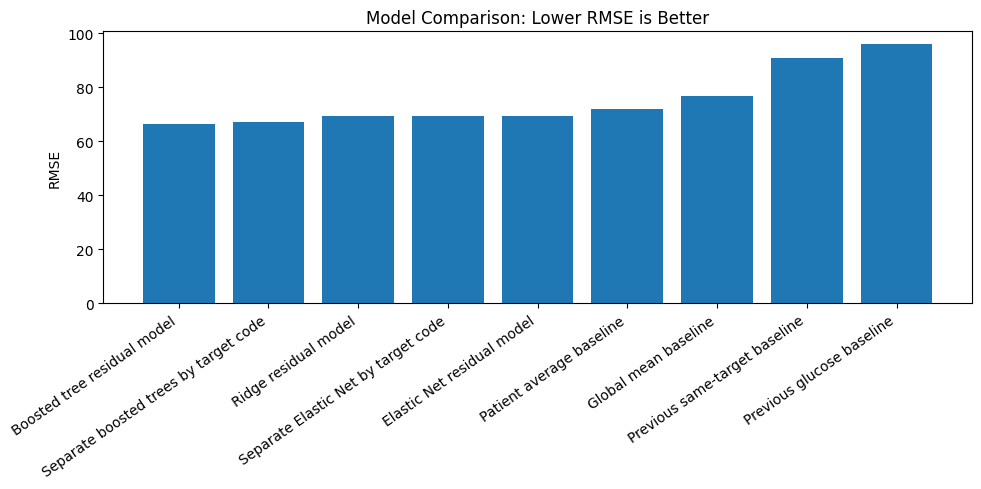

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison: Lower RMSE is Better")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


In [13]:
elastic_pipe = fitted_models["Elastic Net residual model"]
preprocessor = elastic_pipe.named_steps["preprocessor"]
elastic_model = elastic_pipe.named_steps["model"]

# Get transformed training matrix so we can verify the real number of columns.
X_train_transformed = preprocessor.transform(X_train)
coefs_raw = elastic_model.coef_

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{i}" for i in range(X_train_transformed.shape[1])])

# If feature-name count and coefficient count differ, fall back to generic names.
if len(feature_names) != len(coefs_raw):
    print(f"Feature name count: {len(feature_names)}")
    print(f"Coefficient count: {len(coefs_raw)}")
    print("Using generic feature names because the encoder feature names do not match.")
    feature_names = np.array([f"feature_{i}" for i in range(len(coefs_raw))])

coefs = pd.Series(coefs_raw, index=feature_names)

selected_coefs = (
    coefs[coefs.abs() > 1e-8]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Selected predictors:", len(selected_coefs))
selected_coefs.head(20)

Selected predictors: 19


num__prev_same_target_glucose    8.821631
num__regular_insulin_8h         -3.870284
cat__target_code_60             -3.569028
num__hours_since_prev_glucose    3.428612
num__regular_insulin_4h          2.751934
num__prev_glucose                2.168331
num__hours_since_same_target    -2.025252
num__ultralente_insulin_24h     -1.963437
num__time_cos                    1.933891
num__nph_insulin_24h            -1.731899
cat__target_code_58              1.561200
num__hypo_symptoms_24h           1.156253
num__glucose_max_24h             1.046061
num__glucose_mean_7d            -0.927395
num__time_sin                    0.847100
num__special_event_24h          -0.261926
num__regular_insulin_2h          0.169677
num__more_exercise_6h           -0.048136
num__nph_insulin_12h            -0.044286
dtype: float64

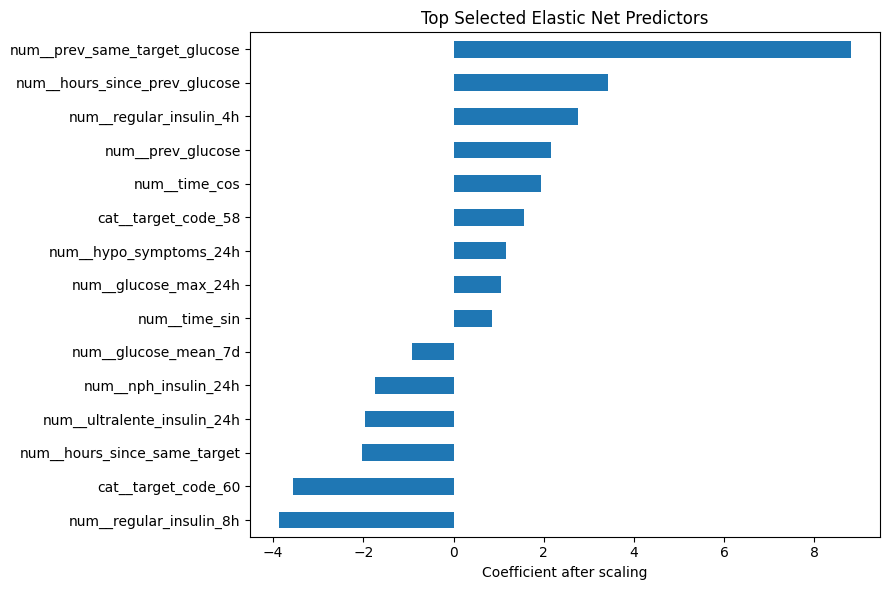

In [14]:
selected_coefs.head(15).sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Top Selected Elastic Net Predictors")
plt.xlabel("Coefficient after scaling")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.inspection import permutation_importance

boosted_pipe = fitted_models["Boosted tree residual model"]

perm = permutation_importance(
    boosted_pipe,
    X_test,
    y_test - y_test_baseline,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
)

importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

importance.head(15)


regular_insulin_8h          2.882043
prev_glucose                2.695257
hours_since_prev_glucose    1.779888
prev_same_target_glucose    1.514649
patientId                   1.095335
time_sin                    0.705480
glucose_mean_48h            0.664671
MinuteOfDay                 0.607972
time_cos                    0.542980
nph_insulin_24h             0.497673
glucose_max_24h             0.413320
regular_insulin_4h          0.376519
glucose_mean_24h            0.306027
glucose_mean_7d             0.270411
hours_since_same_target     0.256103
dtype: float64